Original dataset shape: (284807, 31)
Original missing values per column:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Shape after dropping NaN in Class: (284807, 31)
Missing values after cleaning:
 0

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718 

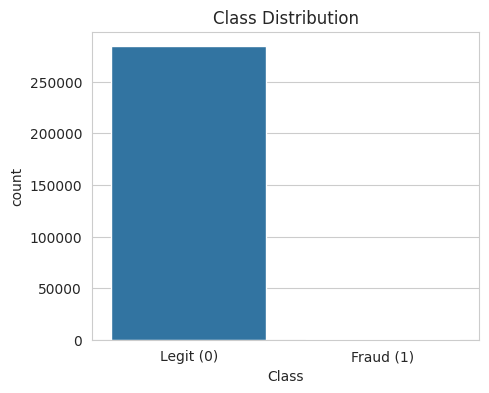


Amount statistics:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Time statistics:
count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64


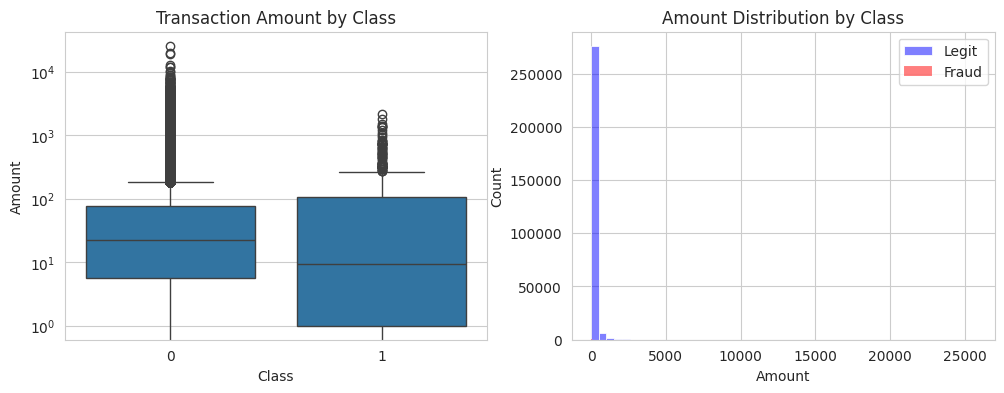

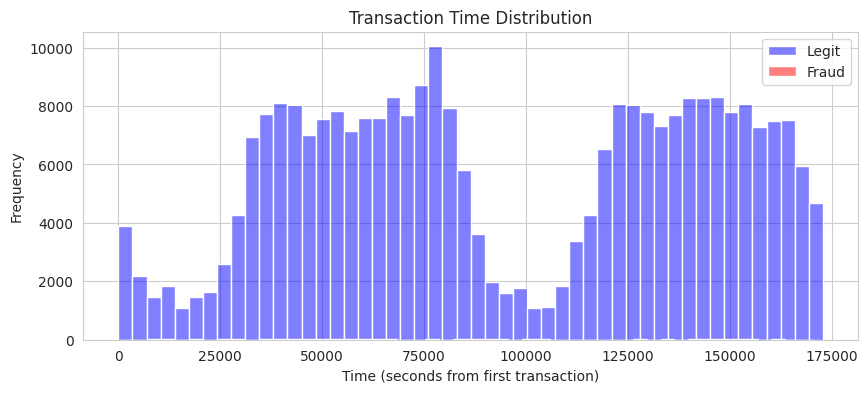

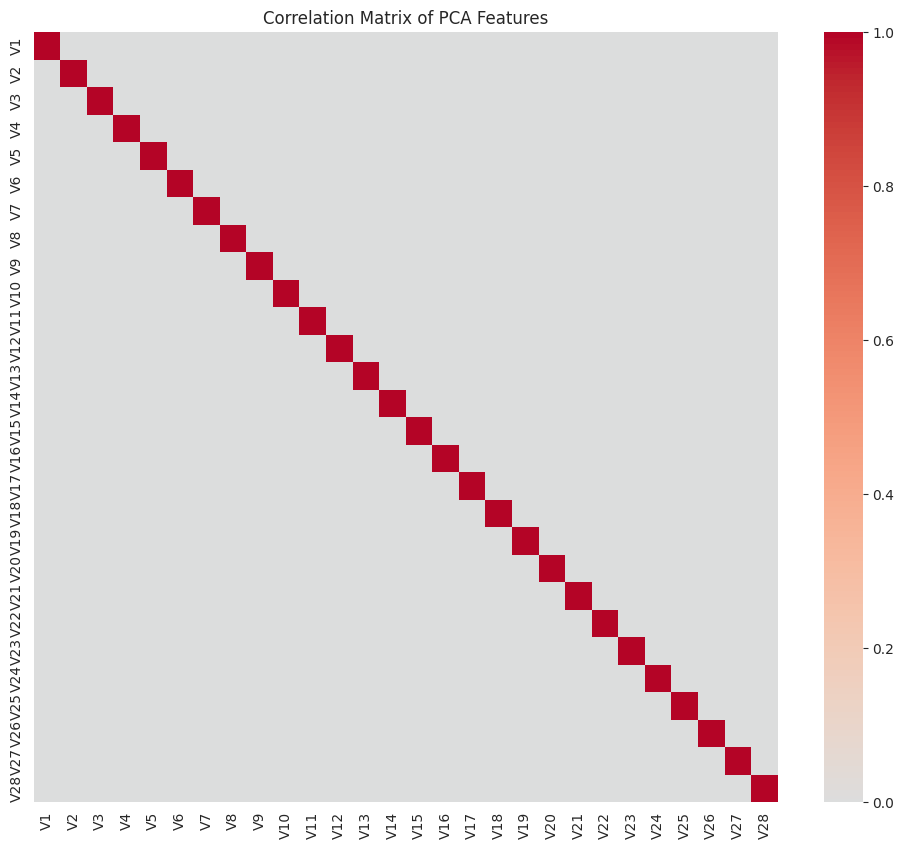


PREPROCESSING
Train set size: (227845, 30)
Test set size: (56962, 30)
Train class distribution:
Class
0    227451
1       394
Name: count, dtype: int64
Test class distribution:
Class
0    56864
1       98
Name: count, dtype: int64

After SMOTE:
Train class distribution:
Class
0    227451
1    227451
Name: count, dtype: int64

MODEL TRAINING AND EVALUATION

Evaluation for Logistic Regression (imbalanced train)
Accuracy:  0.9755
Precision: 0.0609
Recall:    0.9184
F1-score:  0.1141
ROC-AUC:   0.9722
PR-AUC:    0.7189

Confusion Matrix:
[[55475  1389]
 [    8    90]]


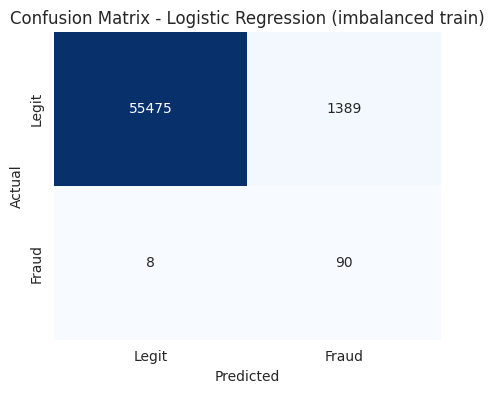


Evaluation for Logistic Regression + SMOTE
Accuracy:  0.9743
Precision: 0.0581
Recall:    0.9184
F1-score:  0.1094
ROC-AUC:   0.9698
PR-AUC:    0.7249

Confusion Matrix:
[[55406  1458]
 [    8    90]]


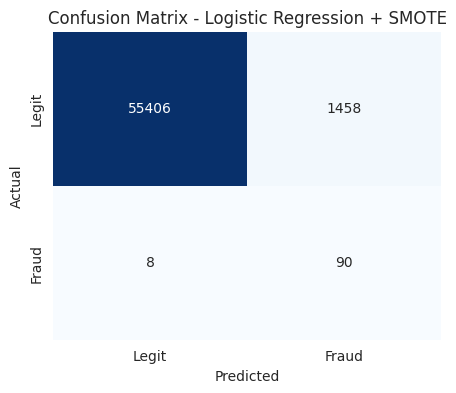


Evaluation for Random Forest (imbalanced train)
Accuracy:  0.9995
Precision: 0.9605
Recall:    0.7449
F1-score:  0.8391
ROC-AUC:   0.9529
PR-AUC:    0.8542

Confusion Matrix:
[[56861     3]
 [   25    73]]


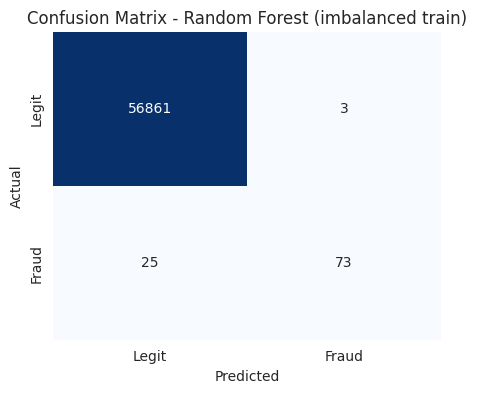


Evaluation for Random Forest + SMOTE
Accuracy:  0.9995
Precision: 0.8454
Recall:    0.8367
F1-score:  0.8410
ROC-AUC:   0.9731
PR-AUC:    0.8747

Confusion Matrix:
[[56849    15]
 [   16    82]]


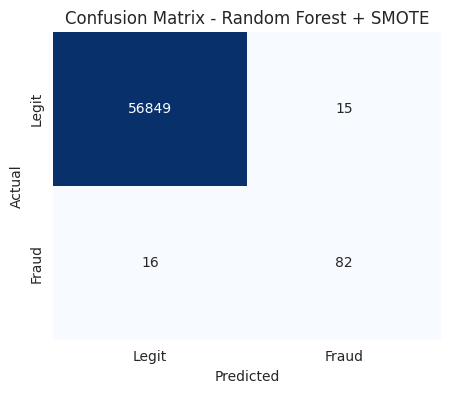

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:26:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Evaluation for XGBoost (imbalanced train)
Accuracy:  0.9995
Precision: 0.8817
Recall:    0.8367
F1-score:  0.8586
ROC-AUC:   0.9682
PR-AUC:    0.8800

Confusion Matrix:
[[56853    11]
 [   16    82]]


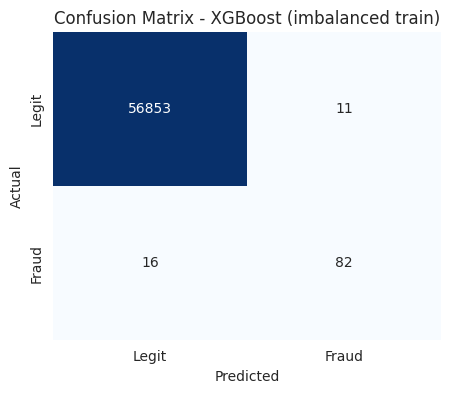


MODEL COMPARISON

Model Performance Comparison:
                                  precision  recall      f1  roc_auc  pr_auc
Logistic Regression (imbalanced)     0.0609  0.9184  0.1141   0.9722  0.7189
Logistic Regression + SMOTE          0.0581  0.9184  0.1094   0.9698  0.7249
Random Forest (imbalanced)           0.9605  0.7449  0.8391   0.9529  0.8542
Random Forest + SMOTE                0.8454  0.8367  0.8410   0.9731  0.8747
XGBoost (imbalanced)                 0.8817  0.8367  0.8586   0.9682  0.8800


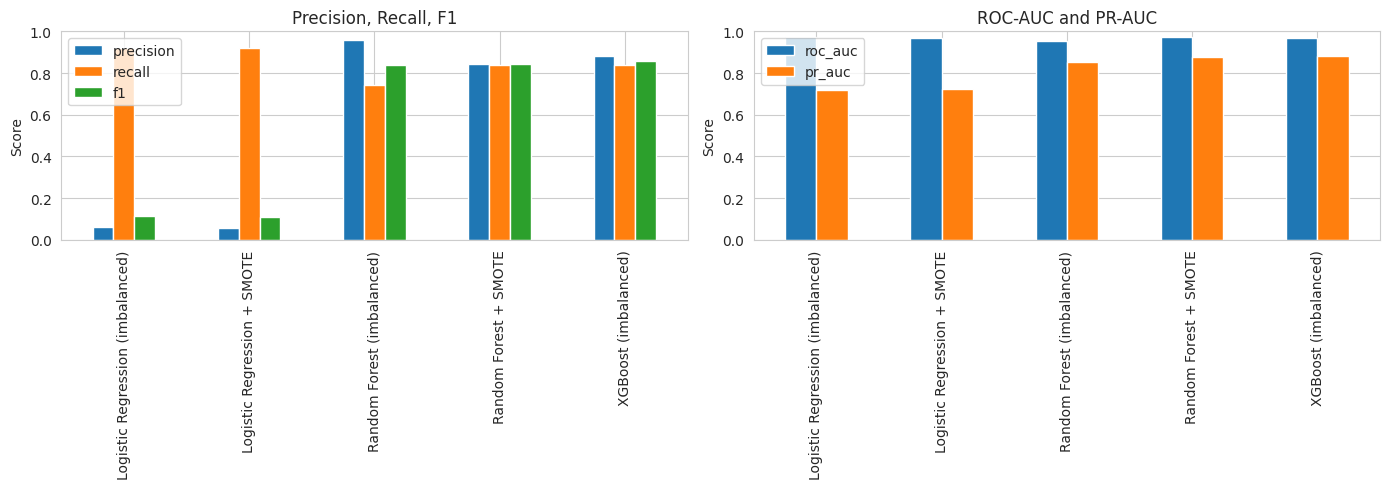

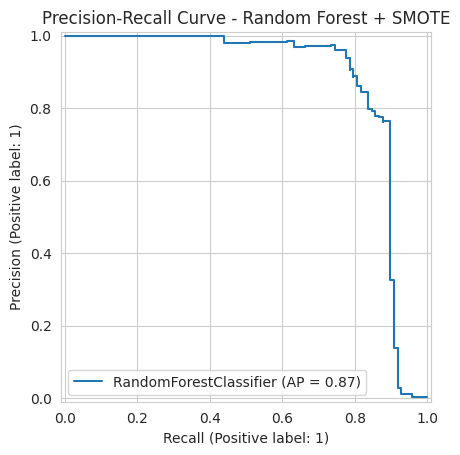


HYPERPARAMETER TUNING (RANDOM FOREST + SMOTE)
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
Best cross-validation F1-score: 0.8400858428807214

Evaluation for Tuned Random Forest + SMOTE
Accuracy:  0.9994
Precision: 0.8367
Recall:    0.8367
F1-score:  0.8367
ROC-AUC:   0.9604
PR-AUC:    0.8640

Confusion Matrix:
[[56848    16]
 [   16    82]]


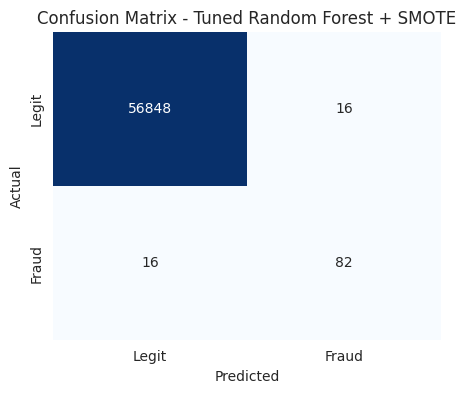


Best model and scaler saved to disk.

PROJECT COMPLETED SUCCESSFULLY


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay
)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost (optional)
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False
    print("XGBoost not installed. Install with: pip install xgboost")

# Joblib for saving model
import joblib

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plotting style
sns.set_style('whitegrid')
# For Jupyter notebook, use %matplotlib inline (uncomment if needed)
# %matplotlib inline


file_path = 'creditcard.csv'   # Update path if needed (e.g., in Google Drive)
df = pd.read_csv(file_path)

print("Original dataset shape:", df.shape)
print("Original missing values per column:\n", df.isnull().sum())

# --- FIX: Drop rows where target (Class) is NaN ---
df = df.dropna(subset=['Class'])
print("\nShape after dropping NaN in Class:", df.shape)
print("Missing values after cleaning:\n", df.isnull().sum().sum())  # should be 0

print("\nFirst 5 rows:")
print(df.head())

# ---------------------------
# 3. Exploratory Data Analysis (EDA)
# ---------------------------
print("\n" + "="*50)
print("EXPLORATORY DATA ANALYSIS")
print("="*50)

# 3.1 Missing values (already done)
# 3.2 Class distribution
class_counts = df['Class'].value_counts()
print("\nClass distribution:\n", class_counts)
fraud_percent = class_counts[1] / len(df) * 100
print(f"Fraudulent transactions: {class_counts[1]} ({fraud_percent:.4f}%)")

# Visualize class imbalance
plt.figure(figsize=(5,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.xticks([0,1], ['Legit (0)', 'Fraud (1)'])
plt.show()

# 3.3 Summary statistics for Amount and Time
print("\nAmount statistics:")
print(df['Amount'].describe())
print("\nTime statistics:")
print(df['Time'].describe())

# 3.4 Amount distribution by class
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0])
axes[0].set_title('Transaction Amount by Class')
axes[0].set_yscale('log')  # log scale because of outliers

sns.histplot(df[df['Class']==0]['Amount'], bins=50, color='blue', label='Legit', alpha=0.5, ax=axes[1])
sns.histplot(df[df['Class']==1]['Amount'], bins=50, color='red', label='Fraud', alpha=0.5, ax=axes[1])
axes[1].set_title('Amount Distribution by Class')
axes[1].set_xlabel('Amount')
axes[1].legend()
plt.show()

# 3.5 Time distribution
plt.figure(figsize=(10,4))
sns.histplot(df[df['Class']==0]['Time'], bins=50, color='blue', label='Legit', alpha=0.5)
sns.histplot(df[df['Class']==1]['Time'], bins=50, color='red', label='Fraud', alpha=0.5)
plt.title('Transaction Time Distribution')
plt.xlabel('Time (seconds from first transaction)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# 3.6 Correlation matrix of PCA features (V1-V28)
plt.figure(figsize=(12,10))
corr = df.iloc[:,1:29].corr()  # exclude Time, Amount, Class
sns.heatmap(corr, cmap='coolwarm', center=0, cbar=True)
plt.title('Correlation Matrix of PCA Features')
plt.show()


print("\n" + "="*50)
print("PREPROCESSING")
print("="*50)

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Scale 'Time' and 'Amount' (important for distance-based models)
scaler = StandardScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

# Train-test split (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Train class distribution:\n{y_train.value_counts()}")
print(f"Test class distribution:\n{y_test.value_counts()}")

# Apply SMOTE only to training data
smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"Train class distribution:\n{pd.Series(y_train_resampled).value_counts()}")


def evaluate_model(model, X_test, y_test, model_name="Model"):
    """Print and return evaluation metrics."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    print(f"\n{'='*40}")
    print(f"Evaluation for {model_name}")
    print(f"{'='*40}")

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")

    if y_proba is not None:
        roc_auc = roc_auc_score(y_test, y_proba)
        pr_auc = average_precision_score(y_test, y_proba)
        print(f"ROC-AUC:   {roc_auc:.4f}")
        print(f"PR-AUC:    {pr_auc:.4f}")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    # Plot confusion matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
            'roc_auc': roc_auc if y_proba is not None else None,
            'pr_auc': pr_auc if y_proba is not None else None}


print("\n" + "="*50)
print("MODEL TRAINING AND EVALUATION")
print("="*50)

# 6.1 Logistic Regression (with class_weight='balanced')
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)
lr_metrics = evaluate_model(lr, X_test, y_test, "Logistic Regression (imbalanced train)")

# 6.2 Logistic Regression on SMOTE-resampled data
lr_smote = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_smote.fit(X_train_resampled, y_train_resampled)
lr_smote_metrics = evaluate_model(lr_smote, X_test, y_test, "Logistic Regression + SMOTE")

# 6.3 Random Forest (with class_weight='balanced')
rf = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
rf_metrics = evaluate_model(rf, X_test, y_test, "Random Forest (imbalanced train)")

# 6.4 Random Forest on SMOTE data
rf_smote = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf_smote.fit(X_train_resampled, y_train_resampled)
rf_smote_metrics = evaluate_model(rf_smote, X_test, y_test, "Random Forest + SMOTE")

# 6.5 XGBoost (if available)
if xgb_available:
    scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
    xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss',
                        random_state=RANDOM_STATE, use_label_encoder=False)
    xgb.fit(X_train, y_train)
    xgb_metrics = evaluate_model(xgb, X_test, y_test, "XGBoost (imbalanced train)")


print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

results = {
    'Logistic Regression (imbalanced)': lr_metrics,
    'Logistic Regression + SMOTE': lr_smote_metrics,
    'Random Forest (imbalanced)': rf_metrics,
    'Random Forest + SMOTE': rf_smote_metrics
}
if xgb_available:
    results['XGBoost (imbalanced)'] = xgb_metrics

comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.round(4)
print("\nModel Performance Comparison:")
print(comparison_df[['precision', 'recall', 'f1', 'roc_auc', 'pr_auc']])

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14,5))
comparison_df[['precision', 'recall', 'f1']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Precision, Recall, F1')
axes[0].set_ylim([0,1])
axes[0].set_ylabel('Score')

comparison_df[['roc_auc', 'pr_auc']].plot(kind='bar', ax=axes[1])
axes[1].set_title('ROC-AUC and PR-AUC')
axes[1].set_ylim([0,1])
axes[1].set_ylabel('Score')
plt.tight_layout()
plt.show()

# Precision-Recall curve for the best model (e.g., Random Forest + SMOTE)
PrecisionRecallDisplay.from_estimator(rf_smote, X_test, y_test)
plt.title('Precision-Recall Curve - Random Forest + SMOTE')
plt.show()


print("\n" + "="*50)
print("HYPERPARAMETER TUNING (RANDOM FOREST + SMOTE)")
print("="*50)

# Create pipeline with SMOTE and classifier
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

# Parameter grid
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5]
}

# Stratified cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1-score:", grid_search.best_score_)

# Evaluate on test set
best_model = grid_search.best_estimator_
best_metrics = evaluate_model(best_model, X_test, y_test, "Tuned Random Forest + SMOTE")

# ---------------------------
# 9. Save Best Model (Optional)
# ---------------------------
# Save the best model and scaler for future use
joblib.dump(best_model, 'best_model_fraud_detection.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\nBest model and scaler saved to disk.")

print("\n" + "="*50)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*50)

In [ ]:
print(df['Class'].isnull().sum())   # count of missing values
print(df[df['Class'].isnull()])     # show rows with missing Class

1
         Time        V1        V2        V3        V4        V5        V6  \
126841  78123  1.108541 -0.050473  1.268449  1.291681 -0.762998  0.272006   

              V7        V8  V9  ...  V21  V22  V23  V24  V25  V26  V27  V28  \
126841 -0.607627  0.203944 NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

        Amount  Class  
126841     NaN    NaN  

[1 rows x 31 columns]
